# K-Means Clustering Module — Test Notebook

This notebook tests the `KMeansClustering` tool end-to-end:
1. Generate synthetic data
2. Load configuration from YAML
3. Run elbow analysis
4. Run clustering with selected k
5. Generate cluster profile CSVs
6. Verify all outputs

## 0. Setup

In [12]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

# Add project root to sys.path
project_root = Path.cwd().parent.parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f"Project root: {project_root}")

from src.utils.config import load_yaml_config
from src.tools.kmeans_clustering import KMeansClustering

print("All imports successful ✅")

Project root: /Users/mohamedinas/Desktop/interview_sample_spaces/2_sysco_interview/1_main_sample
All imports successful ✅


## 1. Generate Synthetic Test Data

In [13]:
np.random.seed(42)
n = 200

# 4 natural clusters
data = {
    'revenue': np.concatenate([
        np.random.normal(50000, 5000, 50),
        np.random.normal(80000, 8000, 50),
        np.random.normal(120000, 10000, 50),
        np.random.normal(200000, 15000, 50),
    ]),
    'order_count': np.concatenate([
        np.random.normal(100, 20, 50),
        np.random.normal(250, 30, 50),
        np.random.normal(400, 40, 50),
        np.random.normal(600, 50, 50),
    ]),
    'avg_order_value': np.concatenate([
        np.random.normal(500, 50, 50),
        np.random.normal(320, 40, 50),
        np.random.normal(300, 30, 50),
        np.random.normal(333, 25, 50),
    ]),
    'days_since_last_order': np.concatenate([
        np.random.normal(90, 20, 50),
        np.random.normal(30, 10, 50),
        np.random.normal(15, 5, 50),
        np.random.normal(7, 3, 50),
    ]),
    'satisfaction_score': np.concatenate([
        np.random.normal(3.0, 0.5, 50),
        np.random.normal(3.5, 0.4, 50),
        np.random.normal(4.0, 0.3, 50),
        np.random.normal(4.5, 0.2, 50),
    ]),
    'return_rate': np.concatenate([
        np.random.normal(0.15, 0.05, 50),
        np.random.normal(0.10, 0.03, 50),
        np.random.normal(0.08, 0.02, 50),
        np.random.normal(0.05, 0.01, 50),
    ]),
}

df = pd.DataFrame(data)
print(f"Synthetic data shape: {df.shape}")
df.head()

Synthetic data shape: (200, 6)


,revenue,order_count,avg_order_value,days_since_last_order,satisfaction_score,return_rate
0,52483.570765,107.155747,420.278617,105.139772,3.469142,0.219968
1,49308.678494,111.215691,470.031249,71.556694,2.741978,0.196232
2,53238.442691,121.661025,500.262185,107.392118,3.048060,0.152982
3,57615.149282,121.076041,502.349030,117.112757,2.768862,0.117653
4,48829.233126,72.446613,477.496726,98.268698,2.782752,0.184911


## 2. Load Configuration

In [14]:
paths_cfg = load_yaml_config('paths.yaml')
vars_cfg = load_yaml_config('variables.yaml')

kmeans_cfg = vars_cfg['kmeans']
k_range = tuple(kmeans_cfg['k_range'])
selected_k = kmeans_cfg['selected_k']
clustering_features = kmeans_cfg['clustering_features']
profiling_features = kmeans_cfg['profiling_features']
standardize = kmeans_cfg.get('standardize', True)
output_dir = project_root / paths_cfg['kmeans_output']

print(f"k_range:              {k_range}")
print(f"selected_k:           {selected_k}")
print(f"clustering_features:  {clustering_features}")
print(f"profiling_features:   {profiling_features}")
print(f"standardize:          {standardize}")
print(f"output_dir:           {output_dir}")

k_range:              (2, 10)
selected_k:           4
clustering_features:  ['revenue', 'order_count', 'avg_order_value']
profiling_features:   ['days_since_last_order', 'satisfaction_score', 'return_rate']
standardize:          True
output_dir:           /Users/mohamedinas/Desktop/interview_sample_spaces/2_sysco_interview/1_main_sample/data/output/kmeans


## 3. Elbow Analysis

In [15]:
inertias = KMeansClustering.run_elbow_analysis(
    df=df,
    features=clustering_features,
    k_range=k_range,
    output_path=output_dir,
    standardize=standardize,
)

print("Inertia by k:")
for k, inertia in inertias.items():
    print(f"  k={k}  →  inertia={inertia:.2f}")

print(f"\nElbow plot saved to: {output_dir / 'elbow_plot.png'}")

Inertia by k:
  k=2  →  inertia=251.31
  k=3  →  inertia=76.60
  k=4  →  inertia=47.73
  k=5  →  inertia=34.69
  k=6  →  inertia=28.86
  k=7  →  inertia=25.61
  k=8  →  inertia=22.37
  k=9  →  inertia=19.76
  k=10  →  inertia=17.80

Elbow plot saved to: /Users/mohamedinas/Desktop/interview_sample_spaces/2_sysco_interview/1_main_sample/data/output/kmeans/elbow_plot.png


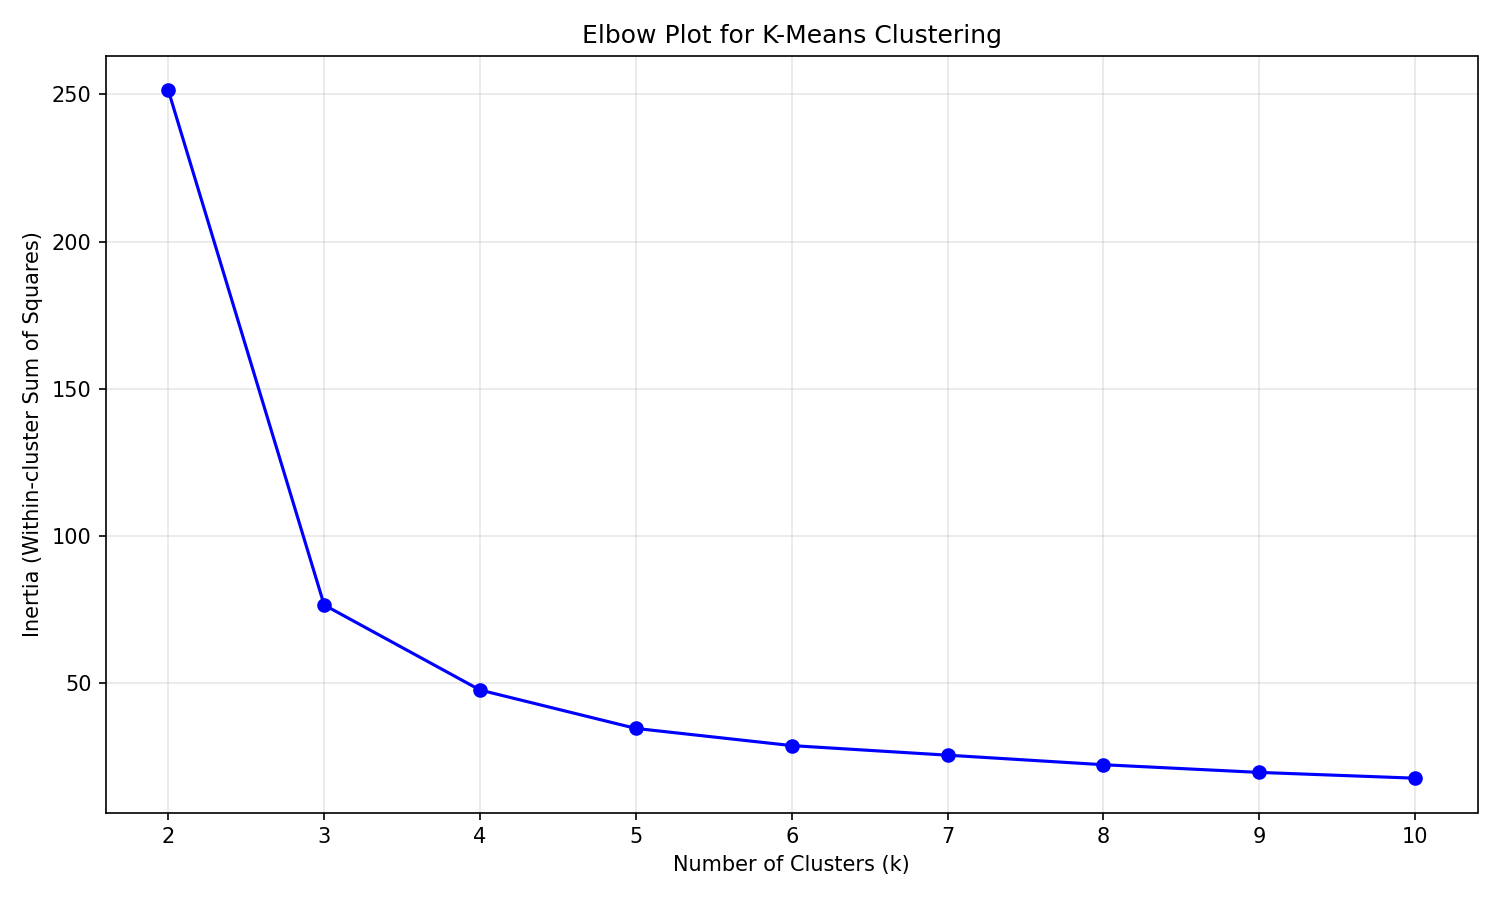

In [16]:
# Display the elbow plot inline
from IPython.display import Image, display

display(Image(filename=str(output_dir / 'elbow_plot.png')))

## 4. Run Clustering

In [17]:
df_clustered = KMeansClustering.run_clustering(
    df=df,
    features=clustering_features,
    k=selected_k,
    standardize=standardize,
)

print(f"Clustered data shape: {df_clustered.shape}")
print(f"\nCluster distribution:")
print(df_clustered['cluster'].value_counts().sort_index())
print()
df_clustered.head(10)

Clustered data shape: (200, 7)

Cluster distribution:
cluster
0    49
1    50
2    51
3    50
Name: count, dtype: int64



,revenue,order_count,avg_order_value,days_since_last_order,satisfaction_score,return_rate,cluster
0,52483.570765,107.155747,420.278617,105.139772,3.469142,0.219968,2
1,49308.678494,111.215691,470.031249,71.556694,2.741978,0.196232,2
2,53238.442691,121.661025,500.262185,107.392118,3.048060,0.152982,2
3,57615.149282,121.076041,502.349030,117.112757,2.768862,0.117653,2
4,48829.233126,72.446613,477.496726,98.268698,2.782752,0.184911,2
5,48829.315215,81.243499,531.142497,127.535916,2.845414,0.169674,2
6,57896.064078,110.300705,446.618979,74.524216,3.111067,0.194760,2
7,53837.173646,110.275719,492.881026,65.106906,2.760626,0.181759,2
8,47652.628070,110.300954,506.014782,54.425595,3.627878,0.202478,2
9,52712.800218,177.054630,525.721942,119.920886,2.552696,0.123238,2


## 5. Cluster Profiles

### 5a. Clustering Features Averages

In [18]:
clustering_profiles = KMeansClustering.get_cluster_profiles(df_clustered, clustering_features)
clustering_csv = output_dir / 'clustering_features_averages.csv'
clustering_profiles.to_csv(clustering_csv, index=False)

print(f"Saved → {clustering_csv.name}")
clustering_profiles

Saved → clustering_features_averages.csv


,cluster,revenue,order_count,avg_order_value
0,0,80130.168612,249.308994,314.904392
1,1,201258.451112,609.074944,333.699952
2,2,49497.364900,105.942420,496.495977
3,3,119607.124333,401.287255,292.241722


### 5b. Profiling Features Averages

In [19]:
profiling_profiles = KMeansClustering.get_cluster_profiles(df_clustered, profiling_features)
profiling_csv = output_dir / 'profiling_features_averages.csv'
profiling_profiles.to_csv(profiling_csv, index=False)

print(f"Saved → {profiling_csv.name}")
profiling_profiles

Saved → profiling_features_averages.csv


,cluster,days_since_last_order,satisfaction_score,return_rate
0,0,29.973163,3.637137,0.098873
1,1,7.425825,4.501009,0.049650
2,2,89.636490,3.069303,0.165939
3,3,14.228686,4.015199,0.084984


### 5c. All Features Averages

In [20]:
all_features = clustering_features + profiling_features

all_profiles = KMeansClustering.get_cluster_profiles(df_clustered, all_features)
all_csv = output_dir / 'all_features_averages.csv'
all_profiles.to_csv(all_csv, index=False)

print(f"Saved → {all_csv.name}")
all_profiles

Saved → all_features_averages.csv


,cluster,revenue,order_count,avg_order_value,days_since_last_order,satisfaction_score,return_rate
0,0,80130.168612,249.308994,314.904392,29.973163,3.637137,0.098873
1,1,201258.451112,609.074944,333.699952,7.425825,4.501009,0.049650
2,2,49497.364900,105.942420,496.495977,89.636490,3.069303,0.165939
3,3,119607.124333,401.287255,292.241722,14.228686,4.015199,0.084984


### 5d. Clustered Raw Data

In [21]:
clustered_data_csv = output_dir / 'clustered_data.csv'
df_clustered.to_csv(clustered_data_csv, index=False)

print(f"Saved → {clustered_data_csv.name}")
print(f"Shape: {df_clustered.shape}")
print(f"Columns: {list(df_clustered.columns)}")
df_clustered.head()

Saved → clustered_data.csv
Shape: (200, 7)
Columns: ['revenue', 'order_count', 'avg_order_value', 'days_since_last_order', 'satisfaction_score', 'return_rate', 'cluster']


,revenue,order_count,avg_order_value,days_since_last_order,satisfaction_score,return_rate,cluster
0,52483.570765,107.155747,420.278617,105.139772,3.469142,0.219968,2
1,49308.678494,111.215691,470.031249,71.556694,2.741978,0.196232,2
2,53238.442691,121.661025,500.262185,107.392118,3.048060,0.152982,2
3,57615.149282,121.076041,502.349030,117.112757,2.768862,0.117653,2
4,48829.233126,72.446613,477.496726,98.268698,2.782752,0.184911,2


## 6. Verification Summary

In [22]:
expected_files = [
    'elbow_plot.png',
    'clustering_features_averages.csv',
    'profiling_features_averages.csv',
    'all_features_averages.csv',
    'clustered_data.csv',
]

print("Output verification:")
all_ok = True
for f in expected_files:
    p = output_dir / f
    if p.exists():
        print(f"  ✅ {f}  ({p.stat().st_size:,} bytes)")
    else:
        print(f"  ❌ {f}  MISSING")
        all_ok = False

# Verify cluster column
df_check = pd.read_csv(output_dir / 'clustered_data.csv')
assert 'cluster' in df_check.columns, "cluster column missing!"
assert df_check['cluster'].nunique() == selected_k, f"Expected {selected_k} clusters"

# Verify profile shapes
cp = pd.read_csv(output_dir / 'clustering_features_averages.csv')
assert len(cp) == selected_k, f"Expected {selected_k} rows in clustering profiles"

pp = pd.read_csv(output_dir / 'profiling_features_averages.csv')
assert len(pp) == selected_k, f"Expected {selected_k} rows in profiling profiles"

ap = pd.read_csv(output_dir / 'all_features_averages.csv')
assert len(ap) == selected_k, f"Expected {selected_k} rows in all profiles"

print(f"\n{'All checks passed! ✅' if all_ok else 'Some checks failed ❌'}")

Output verification:
  ✅ elbow_plot.png  (52,104 bytes)
  ✅ clustering_features_averages.csv  (277 bytes)
  ✅ profiling_features_averages.csv  (291 bytes)
  ✅ all_features_averages.csv  (552 bytes)
  ✅ clustered_data.csv  (22,792 bytes)

All checks passed! ✅
